# Student performance: early warning and support priorities
STDS 36103, Assessment Task 2 (group project). Code appendix.

**Data:** Portuguese-course file of the Student Performance Data Set (`student-por.csv`, 649 students, 33 variables).
Cortez and Silva (2008); UCI Machine Learning Repository; Kaggle copy (CC0 licence).

**Research questions**
1. **RQ1.** Can a student's first-term grade (G1) show early in the year whether the student is likely to fail the final grade (G3 below 10)? Method: logistic regression.
2. **RQ2.** Which study and lifestyle habits (weekly study time, school-day alcohol use, going out with friends) are linked to higher or lower final grades? Method: multiple linear regression.
3. **RQ3.** Which groups of students have lower final grades (past class failures, school MS, no plans for higher education)? Method: the same multiple linear regression, plus fail rates by group.

## 0. Setup

In [1]:
import json
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import KFold, StratifiedKFold
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Fixed random seed, so the cross-validation folds are the same on every run
RNG = 42

os.makedirs("figures", exist_ok=True)

def save(fig, name):
    """Tidy the layout, write the figure to figures/<name>.png and show it."""
    fig.tight_layout()
    fig.savefig(f"figures/{name}.png", dpi=200, bbox_inches="tight")
    plt.show()

## 1. Data checks

In [2]:
df = pd.read_csv("student-por.csv")

# Pass mark is 10 out of 20, so fail = 1 when the final grade G3 is below 10
df["fail"] = (df.G3 < 10).astype(int)

n_missing = int(df.isna().sum().sum())
n_duplicates = int(df.duplicated().sum())

print("Shape:", df.shape, "| missing:", n_missing, "| duplicates:", n_duplicates)
print("Sex:", df.sex.value_counts().to_dict(), "| age range:", df.age.min(), "to", df.age.max())
print("Failed (G3 < 10):", int(df.fail.sum()), f"({df.fail.mean():.1%})")
print("Mean G3:", round(df.G3.mean(), 2), "| median:", df.G3.median())

Shape: (649, 34) | missing: 0 | duplicates: 0
Sex: {'F': 383, 'M': 266} | age range: 15 to 22
Failed (G3 < 10): 100 (15.4%)
Mean G3: 11.91 | median: 12.0


Fifteen students have `G3 = 0`. All fifteen have zero absences and a non-zero term-1 grade, which points to students who did not sit the final exam.
We keep them in the analysis and count them as fails, because a school would want to flag them. Section 5 checks how much they affect the regression.

G3 = 0: 15 | absences = 0: 15 | G2 = 0: 7 | at school MS: 14


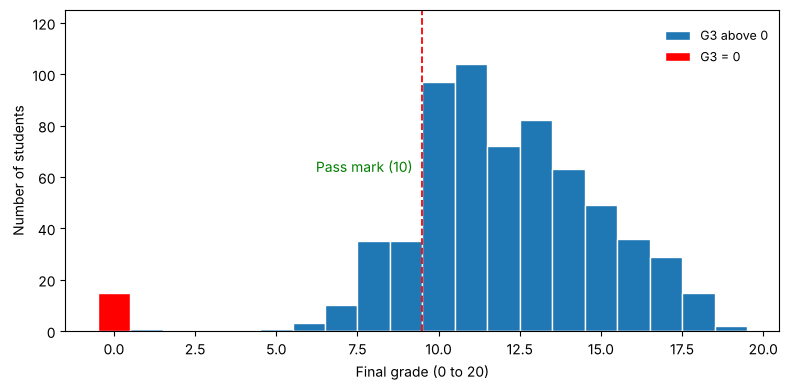

In [3]:
zero = df[df.G3 == 0]

print(
    "G3 = 0:", len(zero),
    "| absences = 0:", int((zero.absences == 0).sum()),
    "| G2 = 0:", int((zero.G2 == 0).sum()),
    "| at school MS:", int((zero.school == "MS").sum()),
)

fig, ax = plt.subplots(figsize=(8, 4))

# One histogram bin per grade (0 to 20); the zero-grade students are drawn in red
bins = np.arange(-0.5, 20.5, 1)
ax.hist(df.G3[df.G3 > 0], bins=bins, edgecolor="white", label="G3 above 0")
ax.hist(df.G3[df.G3 == 0], bins=bins, color="red", edgecolor="white", label="G3 = 0")

# Pass mark line
ax.axvline(9.5, color="red", ls="--", lw=1.3)
ax.text(9.2, 62, "Pass mark (10)", ha="right", color="green", fontsize=10)

ax.set(xlabel="Final grade (0 to 20)", ylabel="Number of students")
ax.set_ylim(0, 125)
ax.legend(frameon=False, loc="upper right", bbox_to_anchor=(1.0, 0.98), fontsize=9)

save(fig, "fig1_g3_distribution")

### 1.1 Which survey variables move with G3?
A quick look before modelling: correlation of each numeric survey variable with the final grade. Past failures, study time, parents' education and alcohol use stand out, which matches the variables used for RQ2 and RQ3.
Mother's and father's education are correlated with each other (r = 0.65), so they carry nearly the same information.

failures     -0.39
Dalc         -0.20
Walc         -0.18
traveltime   -0.13
freetime     -0.12
age          -0.11
health       -0.10
absences     -0.09
goout        -0.09
famrel        0.06
Fedu          0.21
Medu          0.24
studytime     0.25
Medu vs Fedu: r = 0.65


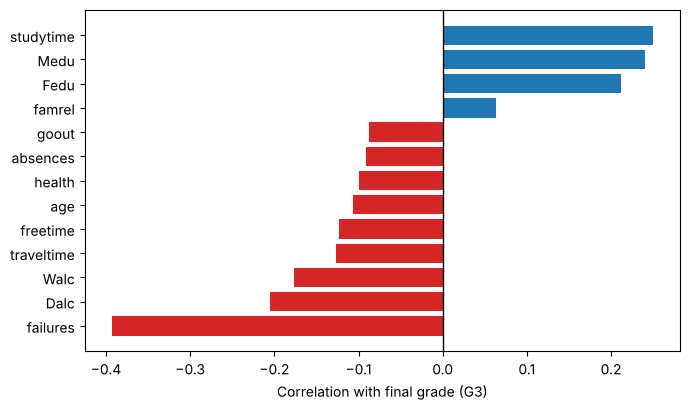

In [4]:
num_cols = [c for c in df.select_dtypes("number").columns if c not in ["G1", "G2", "G3", "fail", "g1_low"]]
corr_g3 = df[num_cols].corrwith(df.G3).sort_values()
print(corr_g3.round(2).to_string())
print("Medu vs Fedu: r =", round(df.Medu.corr(df.Fedu), 2))

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.barh(corr_g3.index, corr_g3.values, color=["C3" if v < 0 else "C0" for v in corr_g3.values])
ax.axvline(0, lw=1, color="black")
ax.set(xlabel="Correlation with final grade (G3)")
save(fig, "fig_eda_correlations")

## 2. RQ1: does the term-1 grade (G1) warn us early? (logistic regression)

Outcome: `fail = 1` if G3 is below 10. Predictor: G1. We first compare fail rates for students below and at or above the pass mark in term 1,
then fit a logistic regression and read the coefficient as an odds ratio.

In [5]:
# g1_low = 1 when the student is below the pass mark in term 1
df["g1_low"] = (df.G1 < 10).astype(int)

# 2 x 2 table: rows = low G1 (0/1), columns = failed (0/1)
ct = pd.crosstab(df.g1_low, df.fail)
print(ct)

tab = pd.DataFrame({
    "students": ct.sum(axis=1),
    "failed": ct[1],
    "fail_rate": (ct[1] / ct.sum(axis=1)).round(3),
})
print(tab)

# Warning-rule quality: "G1 < 10" used as an early alarm for failing G3
sensitivity = ct.loc[1, 1] / ct[1].sum()   # share of failing students that were flagged
specificity = ct.loc[0, 0] / ct[0].sum()   # share of passing students that were not flagged
ppv = ct.loc[1, 1] / ct.loc[1].sum()       # fail rate among flagged students
n_flagged = ct.loc[1].sum()

print(
    f"Share of fails with G1 < 10 (sensitivity): {sensitivity:.1%} | "
    f"specificity: {specificity:.1%} | "
    f"fail rate if G1 < 10: {ppv:.1%} | "
    f"flagged: {n_flagged}"
)

r_g1 = stats.pearsonr(df.G1, df.G3)[0]
r_g2 = stats.pearsonr(df.G2, df.G3)[0]
print("Correlation with G3: G1 =", round(r_g1, 2), "| G2 =", round(r_g2, 2))

fail      0   1
g1_low         
0       480  12
1        69  88
        students  failed  fail_rate
g1_low                             
0            492      12      0.024
1            157      88      0.561
Share of fails with G1 < 10 (sensitivity): 88.0% | specificity: 87.4% | fail rate if G1 < 10: 56.1% | flagged: 157
Correlation with G3: G1 = 0.83 | G2 = 0.92


In [6]:
# Logistic regression: fail ~ G1
m_rq1 = smf.logit("fail ~ G1", data=df).fit(disp=0)
print(m_rq1.summary().tables[1])

# Odds ratio per one G1 point, with 95% confidence interval
odds_ratio = np.exp(m_rq1.params["G1"])
ci = np.exp(m_rq1.conf_int().loc["G1"])
print(
    f"Odds ratio per G1 point = {odds_ratio:.2f} (95% CI {ci[0]:.2f} to {ci[1]:.2f}), "
    f"p = {m_rq1.pvalues['G1']:.2g}, McFadden R2 = {m_rq1.prsquared:.2f}"
)

# AUC in sample
auc_in = roc_auc_score(df.fail, m_rq1.predict(df))

# AUC with 10-fold cross-validation (out-of-fold predictions)
oof = np.zeros(len(df))
folds = StratifiedKFold(10, shuffle=True, random_state=RNG)
for train_idx, test_idx in folds.split(df, df.fail):
    fold_model = smf.logit("fail ~ G1", data=df.iloc[train_idx]).fit(disp=0)
    oof[test_idx] = fold_model.predict(df.iloc[test_idx])
auc_cv = roc_auc_score(df.fail, oof)
print(f"AUC in sample = {auc_in:.3f}, 10-fold cross-validated = {auc_cv:.3f}")

# Predicted probability of failing for a few G1 values
probs = {g: float(m_rq1.predict(pd.DataFrame({"G1": [g]}))[0]) for g in (8, 9, 10, 11)}
print({g: round(p, 3) for g, p in probs.items()})

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     10.0119      1.077      9.294      0.000       7.900      12.123
G1            -1.2153      0.120    -10.165      0.000      -1.450      -0.981
Odds ratio per G1 point = 0.30 (95% CI 0.23 to 0.37), p = 2.8e-24, McFadden R2 = 0.51
AUC in sample = 0.947, 10-fold cross-validated = 0.941
{8: 0.572, 9: 0.284, 10: 0.105, 11: 0.034}


### Checks for the logistic model
With one predictor, the main assumption is that the log-odds of failing change linearly with G1. We test this by adding a squared term (likelihood-ratio test)
and by comparing observed and fitted fail rates at each G1 level.

Squared term: LR = 21.2, p = 4.1e-06
      n  observed  fitted
G1c                      
5     8     0.875   0.981
6     9     0.889   0.938
7    33     0.818   0.818
8    42     0.667   0.572
9    65     0.277   0.284
10   95     0.105   0.105
11   91     0.022   0.034
12   82     0.000   0.010
13   72     0.000   0.003
14   71     0.000   0.001
15   35     0.000   0.000
16   46     0.000   0.000


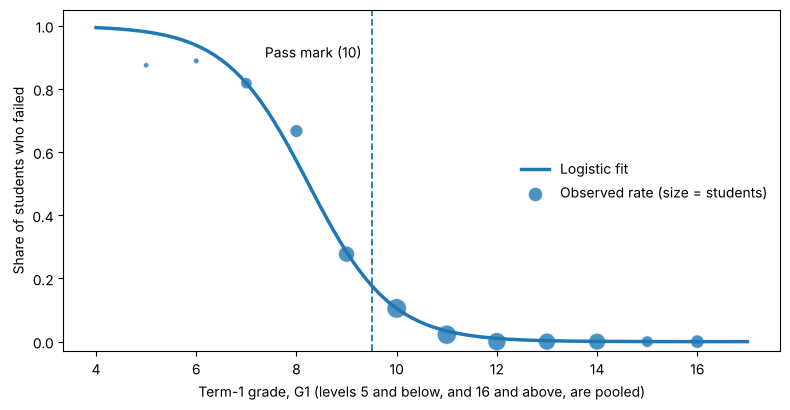

In [7]:
# Likelihood-ratio test: does adding G1 squared improve the model?
m_quad = smf.logit("fail ~ G1 + I(G1**2)", data=df).fit(disp=0)
lr_stat = 2 * (m_quad.llf - m_rq1.llf)
p_lr = stats.chi2.sf(lr_stat, 1)
print(f"Squared term: LR = {lr_stat:.1f}, p = {p_lr:.2g}")

# Observed vs fitted fail rate at each G1 level (levels below 5 and above 16 are pooled)
levels = (
    df.assign(G1c=df.G1.clip(5, 16))
    .groupby("G1c")
    .agg(n=("fail", "size"), observed=("fail", "mean"))
)
levels["fitted"] = m_rq1.predict(pd.DataFrame({"G1": levels.index})).values
print(levels.round(3))

# Figure: fitted curve and observed rates
fig, ax = plt.subplots(figsize=(8, 4.2))

x_grid = np.linspace(4, 17, 100)
ax.plot(x_grid, m_rq1.predict(pd.DataFrame({"G1": x_grid})), lw=2.5, label="Logistic fit")
ax.scatter(
    levels.index, levels.observed,
    s=levels.n * 2.2, alpha=0.8, edgecolor="white",
    label="Observed rate (size = students)",
)

ax.axvline(9.5, ls="--", lw=1.3)
ax.text(9.3, 0.9, "Pass mark (10)", ha="right", fontsize=10)

ax.set(
    xlabel="Term-1 grade, G1 (levels 5 and below, and 16 and above, are pooled)",
    ylabel="Share of students who failed",
    ylim=(-0.03, 1.05),
)
ax.legend(frameon=False, loc="center right")

save(fig, "fig2_rq1_logistic")

### RQ1 sensitivity checks
The squared-term test above rejects a straight line on the log-odds scale. Three further checks show how much this matters:
(a) compare linear, quadratic and spline forms by AIC and cross-validated AUC; (b) refit without the 15 students with `G3 = 0`, who most likely skipped the final exam;
(c) show what each possible cut-off for the "G1 below c" warning rule would catch and miss.

In [8]:
def cv_auc(formula, data):
    """10-fold cross-validated AUC for a logistic model written as a formula."""
    oof = np.zeros(len(data))
    for tr, te in StratifiedKFold(10, shuffle=True, random_state=RNG).split(data, data.fail):
        m = smf.logit(formula, data=data.iloc[tr]).fit(disp=0)
        oof[te] = m.predict(data.iloc[te])
    return roc_auc_score(data.fail, oof)

forms = {
    "Linear in G1 (main model)": "fail ~ G1",
    "Quadratic in G1": "fail ~ G1 + I(G1**2)",
    "Cubic spline in G1 (4 df)": "fail ~ bs(G1, df=4, degree=3, lower_bound=0, upper_bound=20)",
}
at8 = pd.DataFrame({"G1": [8]})
rows = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")          # the spline fits in some CV folds warn about convergence
    for name, f in forms.items():
        m = smf.logit(f, data=df).fit(disp=0)
        rows.append({"model": name, "n": int(m.nobs), "AIC": round(m.aic, 1),
                     "CV AUC": round(cv_auc(f, df), 3), "risk at G1 = 8": round(float(m.predict(at8)[0]), 3)})

    # (b) Linear model without the 15 students with G3 = 0
    nz_rq1 = df[df.G3 > 0]
    m_nz = smf.logit("fail ~ G1", data=nz_rq1).fit(disp=0)
    rows.append({"model": "Linear, without G3 = 0", "n": int(m_nz.nobs), "AIC": round(m_nz.aic, 1),
                 "CV AUC": round(cv_auc("fail ~ G1", nz_rq1), 3), "risk at G1 = 8": round(float(m_nz.predict(at8)[0]), 3)})

print(pd.DataFrame(rows).to_string(index=False))
or_nz = np.exp(m_nz.params["G1"]); ci_nz = np.exp(m_nz.conf_int().loc["G1"])
print(f"Without G3 = 0: odds ratio per G1 point = {or_nz:.2f} (95% CI {ci_nz[0]:.2f} to {ci_nz[1]:.2f})")

# (c) Cut-off table for the warning rule "flag if G1 < c"
cut_rows = []
for c in (9, 10, 11, 12):
    flag = df.G1 < c
    tp = int((flag & (df.fail == 1)).sum()); fp = int((flag & (df.fail == 0)).sum())
    fn = int((~flag & (df.fail == 1)).sum()); tn = int((~flag & (df.fail == 0)).sum())
    cut_rows.append({"cut-off": f"G1 < {c}", "flagged": tp + fp, "fails caught %": round(100 * tp / (tp + fn), 1),
                     "specificity %": round(100 * tn / (tn + fp), 1), "fail rate among flagged %": round(100 * tp / (tp + fp), 1),
                     "passers flagged": fp})
print(pd.DataFrame(cut_rows).to_string(index=False))

                    model   n   AIC  CV AUC  risk at G1 = 8
Linear in G1 (main model) 649 279.8   0.941           0.572
          Quadratic in G1 649 260.5   0.942           0.637
Cubic spline in G1 (4 df) 649 262.6   0.940           0.625
   Linear, without G3 = 0 634 263.3   0.939           0.539
Without G3 = 0: odds ratio per G1 point = 0.30 (95% CI 0.24 to 0.39)
cut-off  flagged  fails caught %  specificity %  fail rate among flagged %  passers flagged
 G1 < 9       92            70.0           96.0                       76.1               22
G1 < 10      157            88.0           87.4                       56.1               69
G1 < 11      252            98.0           71.9                       38.9              154
G1 < 12      343           100.0           55.7                       29.2              243


## 3. Variable selection for RQ2 and RQ3

G1 and G2 are earlier grades in the same subject and correlate strongly with G3, so they stay out of this model. They also sit between the habits and the final grade (a student who studies more tends to score higher in term 1, and term 1 feeds the final grade), so adjusting for them would hide part of the habit effect that RQ2 asks about. The candidates are the other survey variables:
categorical variables are dummy coded (39 columns). Figure 3 shows that students who go out very rarely or very often fail more often than the middle groups,
so we add one yes/no variable, `goext` (going out = 1 or 5). Backward elimination and forward selection both use a 0.01 threshold, because 40 candidates raise the chance of a false positive.

In [9]:
# Candidate predictors: everything except the grades and the outcome columns
X = df.drop(columns=["G1", "G2", "G3", "fail", "g1_low"])

# Dummy coding for text columns (drop_first avoids perfect collinearity)
categorical_cols = list(X.select_dtypes(exclude="number").columns)
Xd = pd.get_dummies(X, columns=categorical_cols, drop_first=True).astype(float)
print("Dummy-coded candidate variables:", Xd.shape[1])

# Extra yes/no variable: goes out very rarely (1) or very often (5)
Xd["goext"] = df.goout.isin([1, 5]).astype(float)
print("Candidates including goext:", Xd.shape[1])

# Outcome for the linear model
y = df.G3

Dummy-coded candidate variables: 39
Candidates including goext: 40


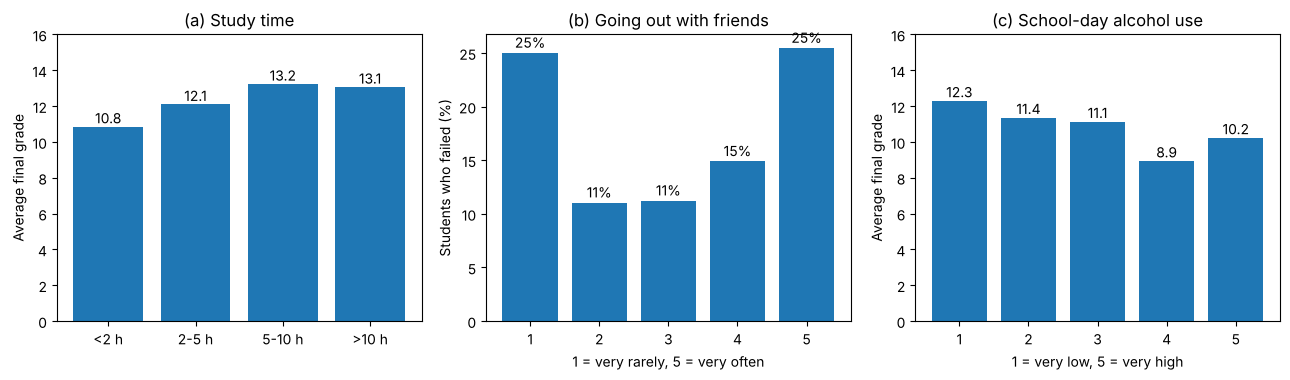

In [10]:
# Figure 3: three habits and the outcome
fig, ax = plt.subplots(1, 3, figsize=(13, 3.9))

# (a) Study time vs average final grade
study_mean = df.groupby("studytime").G3.mean()
ax[0].bar(["<2 h", "2-5 h", "5-10 h", ">10 h"], study_mean.values)
ax[0].set(title="(a) Study time", ylabel="Average final grade", ylim=(0, 16))
for i, v in enumerate(study_mean.values):
    ax[0].text(i, v + 0.2, f"{v:.1f}", ha="center", fontsize=10)

# (b) Going out vs fail rate
goout_fail = df.groupby("goout").fail.mean() * 100
ax[1].bar(goout_fail.index.astype(str), goout_fail.values)
ax[1].set(
    title="(b) Going out with friends",
    xlabel="1 = very rarely, 5 = very often",
    ylabel="Students who failed (%)",
)
for i, v in enumerate(goout_fail.values):
    ax[1].text(i, v + 0.5, f"{v:.0f}%", ha="center", fontsize=10)

# (c) School-day alcohol vs average final grade
alcohol_mean = df.groupby("Dalc").G3.mean()
ax[2].bar(alcohol_mean.index.astype(str), alcohol_mean.values)
ax[2].set(
    title="(c) School-day alcohol use",
    xlabel="1 = very low, 5 = very high",
    ylabel="Average final grade",
    ylim=(0, 16),
)
for i, v in enumerate(alcohol_mean.values):
    ax[2].text(i, v + 0.2, f"{v:.1f}", ha="center", fontsize=10)

save(fig, "fig3_habits")

In [11]:
def backward(X_data, y_data, threshold):
    """Backward elimination: drop the variable with the largest p-value until all are below the threshold."""
    cols = list(X_data.columns)
    while True:
        model = sm.OLS(y_data, sm.add_constant(X_data[cols])).fit()
        pvals = model.pvalues.drop("const")
        worst = pvals.idxmax()
        if pvals[worst] > threshold:
            cols.remove(worst)
        else:
            return cols


def forward(X_data, y_data, threshold):
    """Forward selection: add the variable with the smallest p-value while it is below the threshold."""
    chosen, remaining = [], list(X_data.columns)
    while remaining:
        pvals = {
            c: sm.OLS(y_data, sm.add_constant(X_data[chosen + [c]])).fit().pvalues[c]
            for c in remaining
        }
        best = min(pvals, key=pvals.get)
        if pvals[best] < threshold:
            chosen.append(best)
            remaining.remove(best)
        else:
            break
    return chosen


ALPHA = 0.01
bwd = backward(Xd, y, ALPHA)
fwd = forward(Xd, y, ALPHA)

print("Backward elimination keeps", len(bwd), ":", sorted(bwd))
print("Forward selection keeps  ", len(fwd), ":", sorted(fwd))
print(
    "Shared:", len(set(bwd) & set(fwd)),
    "| only backward:", sorted(set(bwd) - set(fwd)),
    "| only forward:", sorted(set(fwd) - set(bwd)),
)

Backward elimination keeps 9 : ['Dalc', 'Fedu', 'failures', 'goext', 'health', 'higher_yes', 'school_MS', 'schoolsup_yes', 'studytime']
Forward selection keeps   9 : ['Dalc', 'Medu', 'failures', 'goext', 'health', 'higher_yes', 'school_MS', 'schoolsup_yes', 'studytime']
Shared: 8 | only backward: ['Fedu'] | only forward: ['Medu']


## 4. Final linear model (RQ2 and RQ3)
Outcome G3 (0 to 20), n = 649. Predictors are the nine variables kept by backward elimination.
RQ2 reads the habit variables (`studytime`, `Dalc`, `goext`). RQ3 reads the group variables (`failures`, `school_MS`, `higher_yes`, `schoolsup_yes`). `Fedu` and `health` are controls.

In [12]:
# Final model: ordinary least squares, and the same model with HC3 robust standard errors
design = sm.add_constant(Xd[bwd])
ols = sm.OLS(y, design).fit()
rob = sm.OLS(y, design).fit(cov_type="HC3")

# Readable names and the role of each variable
label = {
    "higher_yes": "Plans higher education (yes)",
    "studytime": "Weekly study time (per level)",
    "Dalc": "School-day alcohol (per level)",
    "goext": "Goes out very rarely or very often (yes)",
    "failures": "Past class failures (per failure)",
    "school_MS": "School MS (vs GP)",
    "schoolsup_yes": "Extra school support (yes)",
    "Fedu": "Father's education (per level)",
    "health": "Self-rated health (per level)",
}
role = {
    "studytime": "RQ2 habit",
    "Dalc": "RQ2 habit",
    "goext": "RQ2 habit",
    "failures": "RQ3 group",
    "school_MS": "RQ3 group",
    "higher_yes": "RQ3 group",
    "schoolsup_yes": "RQ3 group",
    "Fedu": "control",
    "health": "control",
}

# Coefficient table (robust standard errors)
coef = pd.DataFrame({
    "coef": rob.params,
    "ci_low": rob.conf_int()[0],
    "ci_high": rob.conf_int()[1],
    "p_HC3": rob.pvalues,
}).drop("const")
coef["role"] = coef.index.map(role)
coef.index = coef.index.map(label.get)

print(f"n = {int(ols.nobs)}, R2 = {ols.rsquared:.3f}, adjusted R2 = {ols.rsquared_adj:.3f}, intercept = {ols.params['const']:.2f}")
print(coef.round(3))

n = 649, R2 = 0.327, adjusted R2 = 0.317, intercept = 11.17
                                           coef  ci_low  ci_high  p_HC3  \
Father's education (per level)            0.280   0.082    0.479  0.006   
Weekly study time (per level)             0.503   0.259    0.748  0.000   
Past class failures (per failure)        -1.426  -1.831   -1.020  0.000   
School-day alcohol (per level)           -0.397  -0.676   -0.118  0.005   
Self-rated health (per level)            -0.198  -0.338   -0.058  0.006   
School MS (vs GP)                        -1.360  -1.878   -0.843  0.000   
Extra school support (yes)               -1.288  -1.965   -0.611  0.000   
Plans higher education (yes)              1.713   0.997    2.428  0.000   
Goes out very rarely or very often (yes) -0.778  -1.312   -0.243  0.004   

                                               role  
Father's education (per level)              control  
Weekly study time (per level)             RQ2 habit  
Past class failures (per fa

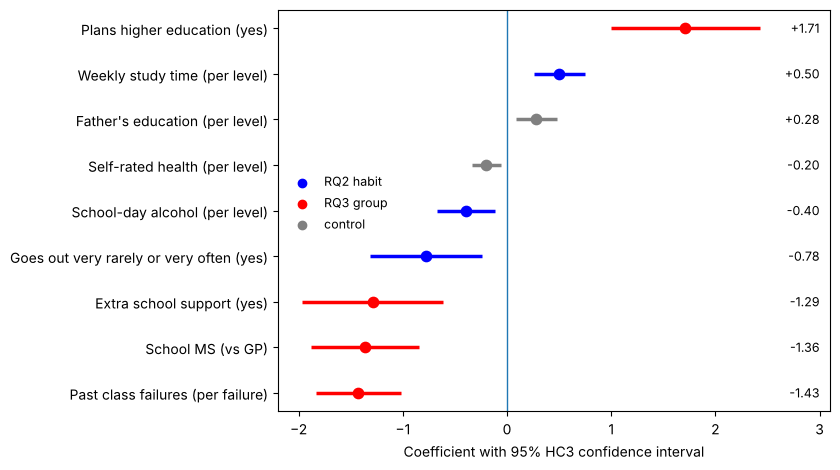

In [13]:
# Figure 4: coefficients with 95% HC3 confidence intervals
coef_sorted = coef.sort_values("coef")
role_colors = {"RQ2 habit": "blue", "RQ3 group": "red", "control": "grey"}

fig, ax = plt.subplots(figsize=(8.5, 4.8))

for i, (name, row) in enumerate(coef_sorted.iterrows()):
    color = role_colors[row.role]
    ax.hlines(i, row.ci_low, row.ci_high, color=color, lw=2.5)
    ax.scatter(row.coef, i, color=color, s=55, zorder=3)
    ax.text(3.0, i, f"{row.coef:+.2f}", va="center", ha="right", fontsize=9)

ax.set_yticks(range(len(coef_sorted)))
ax.set_yticklabels(coef_sorted.index)
ax.axvline(0, lw=1)
ax.set_xlim(-2.2, 3.1)

# Empty scatters only create the legend entries
for role_name, color in role_colors.items():
    ax.scatter([], [], color=color, label=role_name)
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(0.0, 0.62), fontsize=9)

ax.set(xlabel="Coefficient with 95% HC3 confidence interval")

save(fig, "fig4_coefficients")

### 4.1 Fail rates by group (RQ3)

In [14]:
# For each group: how to pick the "comparison" students and how to label both sides
groups = {
    "Past failures": {
        "column": "failures",
        "is_comparison": lambda s: s > 0,
        "ref_label": "None",
        "comp_label": "One or more",
    },
    "Plans higher education": {
        "column": "higher",
        "is_comparison": lambda s: s == "yes",
        "ref_label": "No",
        "comp_label": "Yes",
    },
    "School": {
        "column": "school",
        "is_comparison": lambda s: s == "MS",
        "ref_label": "GP",
        "comp_label": "MS",
    },
}

rows = []
for name, g in groups.items():
    is_comp = g["is_comparison"](df[g["column"]])
    ref_students = df[~is_comp]
    comp_students = df[is_comp]

    rows.append({
        "group": name,
        "reference": g["ref_label"],
        "fail_%": round(ref_students["fail"].mean() * 100, 1),
        "n": len(ref_students),
        "comparison": g["comp_label"],
        "fail_%_comp": round(comp_students["fail"].mean() * 100, 1),
        "n_comp": len(comp_students),
    })

gt = pd.DataFrame(rows)
print(gt)


                    group reference  fail_%    n   comparison  fail_%_comp  \
0           Past failures      None     9.3  549  One or more         49.0   
1  Plans higher education        No    47.8   69          Yes         11.6   
2                  School        GP     7.6  423           MS         30.1   

   n_comp  
0     100  
1     580  
2     226  


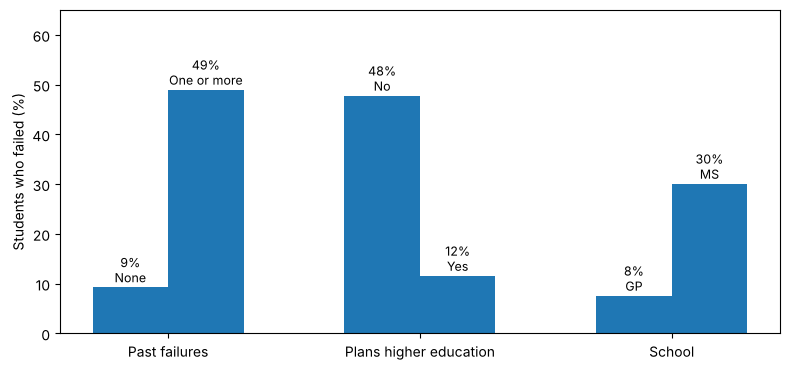

In [15]:
# Figure 5: fail rate by student group
BAR_COLOR = "C0"
BAR_WIDTH = 0.3

fig, ax = plt.subplots(figsize=(8, 3.8))

for i, r in gt.iterrows():
    left_x = i - BAR_WIDTH / 2
    right_x = i + BAR_WIDTH / 2

    ax.bar(left_x, r["fail_%"], BAR_WIDTH, color=BAR_COLOR)
    ax.bar(right_x, r["fail_%_comp"], BAR_WIDTH, color=BAR_COLOR)

    # Label above each bar: percentage on the first line, category name on the second
    ax.text(left_x, r["fail_%"] + 1, f"{r['fail_%']:.0f}%\n{r['reference']}", ha="center", fontsize=9)
    ax.text(right_x, r["fail_%_comp"] + 1, f"{r['fail_%_comp']:.0f}%\n{r['comparison']}", ha="center", fontsize=9)

ax.grid(axis="y", visible=False)
ax.set_xticks(range(len(gt)))
ax.set_xticklabels(gt["group"])
ax.set(ylim=(0, 65), ylabel="Students who failed (%)")

save(fig, "fig5_groups")

### 4.2 Model fixed in advance, parent-education swap and school split
Backward elimination chose the nine variables above from the data, so the p-values and intervals are optimistic. Three checks:
(a) a model whose predictors are fixed in advance from the research questions (the three habits and three group variables, plus sex, age and parents' education as controls), with no selection step;
(b) the selected model with mother's instead of father's education, because forward selection picked that one and the two are correlated;
(c) the selected model fitted separately for each school, because the two schools may differ in more than a single shift.

In [16]:
# (a) Predictors fixed in advance from RQ2 and RQ3
fixed_vars = ["studytime", "Dalc", "goext", "failures", "school_MS", "higher_yes"] + ["sex_M", "age", "Medu", "Fedu"]
fixed_design = sm.add_constant(Xd[fixed_vars])
fixed_ols = sm.OLS(y, fixed_design).fit()
fixed_rob = sm.OLS(y, fixed_design).fit(cov_type="HC3")
print(f"Fixed-in-advance model: R2 = {fixed_ols.rsquared:.3f}, adjusted R2 = {fixed_ols.rsquared_adj:.3f}")
print(pd.DataFrame({"coef": fixed_rob.params, "ci_low": fixed_rob.conf_int()[0],
                    "ci_high": fixed_rob.conf_int()[1], "p_HC3": fixed_rob.pvalues}).round(3).to_string())

# (b) Mother's instead of father's education in the selected model
swap_cols = [c for c in bwd if c != "Fedu"] + ["Medu"]
swap = sm.OLS(y, sm.add_constant(Xd[swap_cols])).fit(cov_type="HC3")
print("\nWith Medu instead of Fedu:", swap.params.round(2).to_dict())

# (c) The selected model fitted within each school (school_MS drops out of each fit)
within_cols = [c for c in bwd if c != "school_MS"]
within = {}
for school in ("GP", "MS"):
    keep = df.school == school
    fit = sm.OLS(y[keep], sm.add_constant(Xd.loc[keep, within_cols])).fit(cov_type="HC3")
    within[f"{school} (n = {int(keep.sum())})"] = fit.params
print("\nCoefficients within each school:")
print(pd.DataFrame(within).drop("const").round(2).to_string())

Fixed-in-advance model: R2 = 0.317, adjusted R2 = 0.306
             coef  ci_low  ci_high  p_HC3
const       6.893   3.668   10.118  0.000
studytime   0.408   0.164    0.651  0.001
Dalc       -0.379  -0.678   -0.080  0.013
goext      -0.815  -1.354   -0.276  0.003
failures   -1.555  -1.962   -1.149  0.000
school_MS  -1.236  -1.766   -0.706  0.000
higher_yes  1.669   0.940    2.398  0.000
sex_M      -0.436  -0.915    0.043  0.075
age         0.210   0.030    0.391  0.022
Medu        0.226  -0.048    0.499  0.106
Fedu        0.160  -0.103    0.423  0.234

With Medu instead of Fedu: {'const': 11.14, 'studytime': 0.49, 'failures': -1.43, 'Dalc': -0.4, 'health': -0.19, 'school_MS': -1.33, 'schoolsup_yes': -1.23, 'higher_yes': 1.7, 'goext': -0.77, 'Medu': 0.27}

Coefficients within each school:
               GP (n = 423)  MS (n = 226)
Fedu                   0.15          0.59
studytime              0.43          0.64
failures              -1.08         -1.94
Dalc                  -0.33    

## 5. Assumption checks and mitigation
Checks: collinearity (VIF), influence (Cook's distance), equal variance (Breusch-Pagan) and normality of residuals (Shapiro-Wilk, Q-Q plot).
Mitigation: HC3 robust standard errors (used above) and a refit without the 15 students with G3 = 0.

Max VIF = 1.19 | max Cook's D = 0.044 | Cook's D > 4/n: 37
Breusch-Pagan p = 2e-05 | Shapiro-Wilk p = 5.7e-13 | residual skew = -0.71
Residual skew without G3 = 0: 0.22 | BP p without G3 = 0: 0.27
                                          all students  without G3 = 0  \
Father's education (per level)                   0.280           0.231   
Weekly study time (per level)                    0.503           0.452   
Past class failures (per failure)               -1.426          -1.227   
School-day alcohol (per level)                  -0.397          -0.353   
Self-rated health (per level)                   -0.198          -0.158   
School MS (vs GP)                               -1.360          -0.838   
Extra school support (yes)                      -1.288          -1.244   
Plans higher education (yes)                     1.713           1.688   
Goes out very rarely or very often (yes)        -0.778          -0.446   

                                          p (without G3 = 0)  

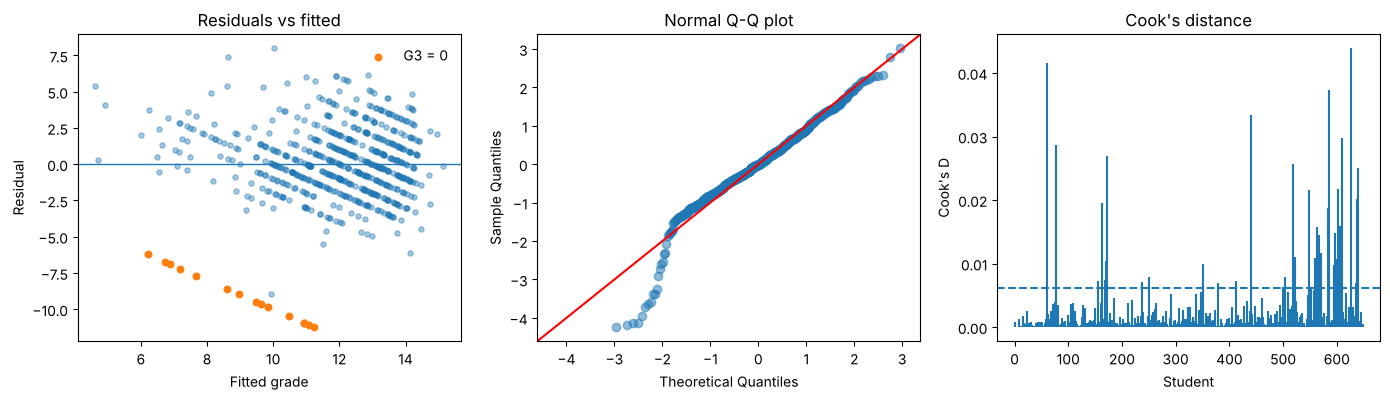

In [17]:
resid = ols.resid
fitted = ols.fittedvalues

# Collinearity: variance inflation factor for each predictor (skip the constant)
design_matrix = sm.add_constant(Xd[bwd]).values
vif = pd.Series(
    [variance_inflation_factor(design_matrix, i) for i in range(1, design_matrix.shape[1])],
    index=bwd,
)

# Influence: Cook's distance
cooks = ols.get_influence().cooks_distance[0]

# Equal variance and normality tests
bp = het_breuschpagan(resid, ols.model.exog)
sw = stats.shapiro(resid)

print(f"Max VIF = {vif.max():.2f} | max Cook's D = {cooks.max():.3f} | Cook's D > 4/n: {(cooks > 4 / len(df)).sum()}")
print(f"Breusch-Pagan p = {bp[1]:.2g} | Shapiro-Wilk p = {sw.pvalue:.2g} | residual skew = {stats.skew(resid):.2f}")

# Same checks without the students who have G3 = 0
nonzero = df.G3 > 0
bp_nonzero = het_breuschpagan(resid[nonzero], ols.model.exog[nonzero])
print(
    "Residual skew without G3 = 0:", round(stats.skew(resid[nonzero]), 2),
    "| BP p without G3 = 0:", f"{bp_nonzero[1]:.2g}",
)

# Refit the model without G3 = 0 and compare coefficients
ols_nz = sm.OLS(y[nonzero], sm.add_constant(Xd.loc[nonzero, bwd])).fit(cov_type="HC3")
cmp = pd.DataFrame({
    "all students": ols.params,
    "without G3 = 0": ols_nz.params,
    "p (without G3 = 0)": ols_nz.pvalues,
}).drop("const")
cmp.index = cmp.index.map(label.get)
print(cmp.round(3))
print("R2 without zeros:", round(ols_nz.rsquared, 3))

# Diagnostic figure
fig, ax = plt.subplots(1, 3, figsize=(14, 4.1))
is_zero = df.G3 == 0

# Residuals vs fitted values
ax[0].scatter(fitted[~is_zero], resid[~is_zero], s=14, alpha=0.4)
ax[0].scatter(fitted[is_zero], resid[is_zero], s=22, label="G3 = 0")
ax[0].axhline(0, lw=1)
ax[0].set(title="Residuals vs fitted", xlabel="Fitted grade", ylabel="Residual")
ax[0].legend(frameon=False)

# Normal Q-Q plot
sm.qqplot(resid, line="45", fit=True, ax=ax[1], alpha=0.5)
ax[1].set_title("Normal Q-Q plot")

# Cook's distance with the 4/n rule-of-thumb line
ax[2].stem(np.arange(len(cooks)), cooks, markerfmt=" ", basefmt=" ")
ax[2].axhline(4 / len(df), ls="--")
ax[2].set(title="Cook's distance", xlabel="Student", ylabel="Cook's D")

save(fig, "figA1_diagnostics")

### 5.1 Out-of-sample check
Stepwise selection can over-fit. We repeat the whole selection inside each training fold (10-fold cross-validation) and compare it with a model that uses all 40 candidates.

In [18]:
def r2_score_manual(y_true, y_pred):
    """R-squared computed by hand: 1 - residual sum of squares / total sum of squares."""
    return 1 - ((y_true - y_pred) ** 2).sum() / ((y_true - y_true.mean()) ** 2).sum()


pred_nested = np.zeros(len(df))   # selection repeated inside each training fold
pred_all = np.zeros(len(df))      # all 40 candidates
pred_fixed = np.zeros(len(df))    # the 9 variables chosen on the full data

for train_idx, test_idx in KFold(10, shuffle=True, random_state=RNG).split(Xd):
    X_train, X_test = Xd.iloc[train_idx], Xd.iloc[test_idx]
    y_train = y.iloc[train_idx]

    # Selection is done on the training fold only
    fold_cols = backward(X_train, y_train, ALPHA)
    pred_nested[test_idx] = LinearRegression().fit(X_train[fold_cols], y_train).predict(X_test[fold_cols])

    pred_all[test_idx] = LinearRegression().fit(X_train, y_train).predict(X_test)
    pred_fixed[test_idx] = LinearRegression().fit(X_train[bwd], y_train).predict(X_test[bwd])

cv_predictions = {
    "selection repeated in each fold": pred_nested,
    "all 40 candidates": pred_all,
    "9 chosen variables (selection outside CV)": pred_fixed,
}
for name, pred in cv_predictions.items():
    rmse = np.sqrt(((y - pred) ** 2).mean())
    print(f"{name}: CV R2 = {r2_score_manual(y, pred):.3f}, RMSE = {rmse:.2f}")

selection repeated in each fold: CV R2 = 0.264, RMSE = 2.77
all 40 candidates: CV R2 = 0.277, RMSE = 2.75
9 chosen variables (selection outside CV): CV R2 = 0.304, RMSE = 2.69


### 5.2 How stable is the variable selection? (bootstrap)
We repeat the whole backward elimination in 500 bootstrap samples of the 649 students. For each variable we count how often it is kept, and we take the 2.5th and 97.5th percentiles of its coefficient
(set to 0 in samples where it is dropped). This interval includes the selection step, unlike the HC3 intervals in Table 1.

In [19]:
B = 500
boot_rng = np.random.default_rng(RNG)
n_obs = len(df)
kept = pd.Series(0.0, index=Xd.columns)
boot_coef = pd.DataFrame(0.0, index=range(B), columns=bwd)

for b in range(B):
    idx = boot_rng.integers(0, n_obs, n_obs)
    Xb = Xd.iloc[idx].reset_index(drop=True)
    yb = y.iloc[idx].reset_index(drop=True)
    cols_b = backward(Xb, yb, ALPHA)
    kept[cols_b] += 1
    fit_b = sm.OLS(yb, sm.add_constant(Xb[cols_b])).fit()
    for c in bwd:
        if c in cols_b:
            boot_coef.loc[b, c] = fit_b.params[c]

stability = pd.DataFrame({
    "kept in % of samples": (100 * kept[bwd] / B).round(0),
    "boot 2.5%": boot_coef.quantile(0.025).round(2),
    "boot 97.5%": boot_coef.quantile(0.975).round(2),
})
stability.index = stability.index.map(label.get)
print(stability.sort_values("kept in % of samples", ascending=False).to_string())
print("Most frequent variables outside the selected nine:",
      (100 * kept.drop(bwd) / B).sort_values(ascending=False).head(3).round(0).to_dict())

                                          kept in % of samples  boot 2.5%  boot 97.5%
Past class failures (per failure)                        100.0      -1.91       -1.05
School MS (vs GP)                                         99.0      -1.92       -0.76
Plans higher education (yes)                              98.0       1.01        2.50
Extra school support (yes)                                88.0      -2.14        0.00
Weekly study time (per level)                             81.0       0.00        0.71
Goes out very rarely or very often (yes)                  73.0      -1.38        0.00
Self-rated health (per level)                             50.0      -0.35        0.00
School-day alcohol (per level)                            44.0      -0.69        0.00
Father's education (per level)                            30.0       0.00        0.47
Most frequent variables outside the selected nine: {'sex_M': 51.0, 'Fjob_teacher': 29.0, 'reason_other': 23.0}


## References
* Cortez, P. (2008). *Student Performance* [Data set]. UCI Machine Learning Repository. https://doi.org/10.24432/C5TG7T
* Cortez, P., & Silva, A. M. G. (2008). Using data mining to predict secondary school student performance. *Proceedings of the 5th FUture BUsiness TEChnology Conference*, 5-12.
* Seabold, S., & Perktold, J. (2010). statsmodels: Econometric and statistical modeling with Python. *Proceedings of the 9th Python in Science Conference*, 92-96.
* Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825-2830.